# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024170394          # <-- your full roll number
NAME = "Dhruv Srivasrava"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170394   Name: Dhruv Srivasrava   Fingerprint: 12224346   Tickets: 16

Ticket_ID                                                                         Ticket_Text
      T01   I tried restarting the LMS when I use mobile hotspot. I have tried several times!
      T02                                         The lms stopped responding. This is urgent.
      T03                                      The Python is not working. Can you check this?
      T04  I tried restarting the projector after resetting my password. It worked yesterday.
      T05         Printer is not working after the latest update. I have tried several times!
      T06           Email stopped responding after restarting the system. Can you check this?
      T07                                                       Why isn't the portal opening?
      T08                         The student portal stopped responding. It worked yesterday.
      T09                                                         

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [6]:
# Your code
processed = {}
rows = []

for _, row in df.iterrows():
    ticket_id = row["Ticket_ID"]
    text = row["Ticket_Text"]

    result = process_ticket(text)
    processed[ticket_id] = result

    rows.append({
        "Ticket_ID": ticket_id,
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique_Tokens": len(set(result["tokens"])),
        "Final_Tokens": len(result["final"])
    })


# Create table
q1_table = pd.DataFrame(rows)


# Add TOTAL row
total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_table["Sentences"].sum(),
    "Tokens": q1_table["Tokens"].sum(),
    "Punctuation": q1_table["Punctuation"].sum(),
    "Stopwords": q1_table["Stopwords"].sum(),
    "Unique_Tokens": q1_table["Unique_Tokens"].sum(),
    "Final_Tokens": q1_table["Final_Tokens"].sum()
}

q1_table = pd.concat(
    [q1_table, pd.DataFrame([total_row])],
    ignore_index=True
)

display(q1_table)

# Select one of the focus tickets generated for this dataset
selected_ticket = FOCUS[0]

result = processed[selected_ticket]

print("Selected Ticket:", selected_ticket)
print("Text:")
print(df.loc[df["Ticket_ID"] == selected_ticket, "Ticket_Text"].iloc[0])

print("\nActual tokens:")
print(result["tokens"])

print("\nPunctuation tokens:")
print(result["punct"])

print("\nStopwords:")
print(result["stops"])

print("\nFinal tokens:")
print(result["final"])

contraction_fragments = {
    "n't", "'s", "'re", "'ve", "'ll", "'d", "'m",
    "ca", "wo", "sha"
}

all_final_tokens = [
    token
    for ticket in processed.values()
    for token in ticket["final"]
]

found_fragments = sorted(
    set(all_final_tokens) & contraction_fragments
)

print("Non-standard fragments found:", found_fragments)

,Ticket_ID,Sentences,Tokens,Punctuation,Stopwords,Unique_Tokens,Final_Tokens
0,T01,2,17,2,6,14,9
1,T02,2,9,2,3,8,4
2,T03,2,11,2,6,11,3
3,T04,2,14,2,5,13,7
4,T05,2,15,2,6,15,7
5,T06,2,13,2,5,13,6
6,T07,1,7,1,3,7,3
7,T08,2,10,2,2,9,6
8,T09,1,7,2,1,7,4
9,T10,2,13,2,6,12,5


Selected Ticket: T10
Text:
The Python is not working. I don't know what changed.

Actual tokens:
['the', 'python', 'is', 'not', 'working', '.', 'i', 'do', "n't", 'know', 'what', 'changed', '.']

Punctuation tokens:
['.', '.']

Stopwords:
['the', 'is', 'not', 'i', 'do', 'what']

Final tokens:
['python', 'working', "n't", 'know', 'changed']
Non-standard fragments found: ["n't"]


**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:* Some final tokens such as n't, ca, and 's are not meaningful standalone words. They are produced because word_tokenize() splits contractions. For example can't may become ca and n't while isn't becomes is and n't. Since some of these fragments are not removed as stopwords they remain in the final token list.

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [7]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

# Your code
import re

LONG_WORD_RE = r"\b[A-Za-z]{6,}\b"
NUMBER_RE = r"\b0[xX][0-9A-Fa-f]+\b|\b\d+(?:\.\d+)+\b|\b\d+(?:,\d{3})*\b"
CAPITAL_RE = r"\b[A-Z][A-Za-z]*(?:-[A-Za-z]+)*\b"
VOWEL_RE = r"\b[AEIOUaeiou][A-Za-z]*(?:[-'][A-Za-z]+)*\b"

def extract_regex_items(text):
    return {
        "Words > 5 letters": re.findall(LONG_WORD_RE, text),
        "Numbers": re.findall(NUMBER_RE, text),
        "Capitalized words": re.findall(CAPITAL_RE, text),
        "Vowel-starting words": re.findall(VOWEL_RE, text)
    }


# Run on own tickets
regex_rows = []

for _, row in df.iterrows():
    extracted = extract_regex_items(row["Ticket_Text"])

    regex_rows.append({
        "Ticket_ID": row["Ticket_ID"],
        "Words > 5 letters": extracted["Words > 5 letters"],
        "Numbers": extracted["Numbers"],
        "Capitalized words": extracted["Capitalized words"],
        "Vowel-starting words": extracted["Vowel-starting words"]
    })

regex_table = pd.DataFrame(regex_rows)

display(regex_table)

print("REGEX EXTRACTION ON TEST_LINES")

for i, line in enumerate(TEST_LINES, start=1):
    print(f"TEST LINE {i}:")
    print(line)

    extracted = extract_regex_items(line)

    print("Words > 5 letters:", extracted["Words > 5 letters"])
    print("Numbers:", extracted["Numbers"])
    print("Capitalized words:", extracted["Capitalized words"])
    print("Vowel-starting words:", extracted["Vowel-starting words"])



EMAIL_RE = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
URL_RE = (
    r"\b(?:https?://|www\.)"
    r"[A-Za-z0-9-]+(?:\.[A-Za-z0-9-]+)+"
    r"(?:/[A-Za-z0-9._~:/?#\[\]@!$&'()*+,;=%-]*"
    r"[A-Za-z0-9/#=_~%-])?"
)
PHONE_RE = (
    r"(?<!\w)"
    r"(?:(?:\+91[-\s]?)?\d{5}[-\s]?\d{5}"
    r"|\d{4}-\d{3}-\d{4})"
    r"(?!\w)"
)

def replace_identifiers(text):
    text = re.sub(EMAIL_RE, "<EMAIL>", text)
    text = re.sub(URL_RE, "<URL>", text)
    text = re.sub(PHONE_RE, "<PHONE>", text)

    return text

print("REPLACEMENT ON OWN TICKETS")

for _, row in df.iterrows():
    original = row["Ticket_Text"]
    replaced = replace_identifiers(original)

    print(row["Ticket_ID"])
    print("Original :", original)
    print("Replaced :", replaced)

print("REPLACEMENT ON TEST_LINES")

for i, line in enumerate(TEST_LINES, start=1):
    print(f"TEST LINE {i}")
    print("Original :", line)
    print("Replaced :", replace_identifiers(line))

from collections import Counter

sentence_start_capitals = []

for text in df["Ticket_Text"]:
    for sentence in sent_tokenize(text):

        first_word = re.search(r"\b[A-Za-z][A-Za-z'-]*\b", sentence)

        if first_word:
            word = first_word.group()

            if word[0].isupper():
                sentence_start_capitals.append(word)

print("Capitalized sentence-start words:")
print(sentence_start_capitals)

print("\nCounts:")
print(Counter(sentence_start_capitals))

print("\nNumber of capitalized sentence-start occurrences:",
      len(sentence_start_capitals))

,Ticket_ID,Words > 5 letters,Numbers,Capitalized words,Vowel-starting words
0,T01,"[restarting, mobile, hotspot, several]",[],"[I, LMS, I, I]","[I, I, use, I]"
1,T02,"[stopped, responding, urgent]",[],"[The, This]","[is, urgent]"
2,T03,"[Python, working]",[],"[The, Python, Can]",[is]
3,T04,"[restarting, projector, resetting, password, w...",[],"[I, It]","[I, after, It]"
4,T05,"[Printer, working, latest, update, several]",[],"[Printer, I]","[is, after, update, I]"
5,T06,"[stopped, responding, restarting, system]",[],"[Email, Can]","[Email, after]"
6,T07,"[portal, opening]",[],[Why],"[isn't, opening]"
7,T08,"[student, portal, stopped, responding, worked,...",[],"[The, It]",[It]
8,T09,[Ticket],[4521],[Ticket],"[is, open]"
9,T10,"[Python, working, changed]",[],"[The, Python, I]","[is, I]"


REGEX EXTRACTION ON TEST_LINES
TEST LINE 1:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
Words > 5 letters: ['helpdesk', 'thapar', 'thapar', 'thapar']
Numbers: []
Capitalized words: ['Mail']
Vowel-starting words: ['it', 'edu', 'or', 'a', 'univ', 'ac', 'in', 'edu', 'or', 'edu', 'it']
TEST LINE 2:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
Words > 5 letters: ['Version']
Numbers: ['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5', '1,250']
Capitalized words: ['Call', 'Version', 'Rs']
Vowel-starting words: ['or', 'is']
TEST LINE 3:
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
Words > 5 letters: []
Numbers: ['5.30']
Capitalized words: ['The']
Vowel-starting words: ['of-the-art', "isn't", 'open', 'in', 'at']
REPLACEMENT ON OWN TICKETS
T01
Original : I tried restarting the LMS when I use mobile hotspot. I have tr

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:* 20

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [8]:
# Your code
from nltk.tokenize import RegexpTokenizer, word_tokenize
import re

TOKEN_PATTERN = r"""
    (?:https?://|www\.)
    [A-Za-z0-9.-]+\.[A-Za-z]{2,}
    (?:/[A-Za-z0-9._~:/?#\[\]@!$&'()*+,;=%-]*
    [A-Za-z0-9/_~#=%-])?

    | [A-Za-z0-9._%+-]+
      @[A-Za-z0-9.-]+
      \.[A-Za-z]{2,}

    | (?:
        (?:\+91[-\s]?)?\d{5}[-\s]?\d{5}
        |
        \d{4}-\d{3}-\d{4}
      )

    | \d+(?:\.\d+)+

    | [A-Za-z]+(?:[-'][A-Za-z]+)+

    | [A-Za-z]+(?:\.[A-Za-z]+)*

    | \d+(?:,\d{3})*

    | [^\w\s]
"""

custom_tokenizer = RegexpTokenizer(
    TOKEN_PATTERN,
    flags=re.VERBOSE | re.IGNORECASE
)


def my_tokenize(text):
    return custom_tokenizer.tokenize(text)


print("=" * 80)
print("CUSTOM TOKENIZER vs word_tokenize() ON TEST_LINES")
print("=" * 80)

for i, line in enumerate(TEST_LINES, start=1):

    custom = my_tokenize(line)
    nltk_tokens = word_tokenize(line)

    print(f"\nTEST LINE {i}:")
    print(line)

    print("\nmy_tokenize():")
    print(custom)

    print("\nword_tokenize():")
    print(nltk_tokens)


comparison_rows = []

for _, row in df.iterrows():

    ticket_id = row["Ticket_ID"]
    text = row["Ticket_Text"]

    custom = my_tokenize(text)
    nltk_tokens = word_tokenize(text)

    comparison_rows.append({
        "Ticket_ID": ticket_id,
        "my_tokenize": custom,
        "word_tokenize": nltk_tokens,
        "Different": custom != nltk_tokens
    })


token_comparison = pd.DataFrame(comparison_rows)

display(token_comparison)


different_count = int(token_comparison["Different"].sum())

print(
    f"\n{different_count} out of {len(df)} tickets "
    "are tokenized differently by my_tokenize() and word_tokenize()."
)


print("\nTickets with different tokenization:\n")

for _, row in token_comparison[token_comparison["Different"]].iterrows():

    print("Ticket:", row["Ticket_ID"])

    print("my_tokenize():")
    print(row["my_tokenize"])

    print("word_tokenize():")
    print(row["word_tokenize"])


CUSTOM TOKENIZER vs word_tokenize() ON TEST_LINES

TEST LINE 1:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.

my_tokenize():
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

word_tokenize():
['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

TEST LINE 2:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.

my_tokenize():
['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

word_tokenize():
['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

TEST LINE 

,Ticket_ID,my_tokenize,word_tokenize,Different
0,T01,"[I, tried, restarting, the, LMS, when, I, use,...","[I, tried, restarting, the, LMS, when, I, use,...",False
1,T02,"[The, lms, stopped, responding, ., This, is, u...","[The, lms, stopped, responding, ., This, is, u...",False
2,T03,"[The, Python, is, not, working, ., Can, you, c...","[The, Python, is, not, working, ., Can, you, c...",False
3,T04,"[I, tried, restarting, the, projector, after, ...","[I, tried, restarting, the, projector, after, ...",False
4,T05,"[Printer, is, not, working, after, the, latest...","[Printer, is, not, working, after, the, latest...",False
5,T06,"[Email, stopped, responding, after, restarting...","[Email, stopped, responding, after, restarting...",False
6,T07,"[Why, isn't, the, portal, opening, ?]","[Why, is, n't, the, portal, opening, ?]",True
7,T08,"[The, student, portal, stopped, responding, .,...","[The, student, portal, stopped, responding, .,...",False
8,T09,"[Ticket, #, 4521, is, still, open, .]","[Ticket, #, 4521, is, still, open, .]",False
9,T10,"[The, Python, is, not, working, ., I, don't, k...","[The, Python, is, not, working, ., I, do, n't,...",True



3 out of 16 tickets are tokenized differently by my_tokenize() and word_tokenize().

Tickets with different tokenization:

Ticket: T07
my_tokenize():
['Why', "isn't", 'the', 'portal', 'opening', '?']
word_tokenize():
['Why', 'is', "n't", 'the', 'portal', 'opening', '?']
Ticket: T10
my_tokenize():
['The', 'Python', 'is', 'not', 'working', '.', 'I', "don't", 'know', 'what', 'changed', '.']
word_tokenize():
['The', 'Python', 'is', 'not', 'working', '.', 'I', 'do', "n't", 'know', 'what', 'changed', '.']
Ticket: T16
my_tokenize():
['Re-installing', "didn't", 'help', ';', 'log-in', 'still', 'fails', '!']
word_tokenize():
['Re-installing', 'did', "n't", 'help', ';', 'log-in', 'still', 'fails', '!']


**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:* 3 out of 16 tickets are tokenized differently by my_tokenize() and word_tokenize().

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [9]:
# Your code
from nltk.stem import (
    PorterStemmer,
    LancasterStemmer,
    RegexpStemmer,
    WordNetLemmatizer
)

import nltk
import re
import pandas as pd

unique_final_tokens = sorted({
    token
    for result in processed.values()
    for token in result["final"]
})

print("Number of unique final tokens:", len(unique_final_tokens))
print("\nUnique final tokens:")
print(unique_final_tokens)

CHOSEN_SUFFIX = "ing"

regexp_stemmer = RegexpStemmer(
    r"ing$",
    min=4
)
ing_words = [
    word for word in unique_final_tokens
    if word.endswith(CHOSEN_SUFFIX)
]

print("\nWords in my dataset ending with 'ing':")
print(ing_words)

porter = PorterStemmer()
lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

def to_wordnet_pos(tag):

    if tag.startswith("J"):
        return "a"       # adjective

    elif tag.startswith("V"):
        return "v"       # verb

    elif tag.startswith("N"):
        return "n"       # noun

    elif tag.startswith("R"):
        return "r"       # adverb

    else:
        return "n"       # default noun

tagged_tokens = nltk.pos_tag(unique_final_tokens)

rows = []

for word, nltk_pos in tagged_tokens:

    wordnet_pos = to_wordnet_pos(nltk_pos)

    porter_output = porter.stem(word)
    lancaster_output = lancaster.stem(word)
    regexp_output = regexp_stemmer.stem(word)

    lemma_output = lemmatizer.lemmatize(
        word,
        pos=wordnet_pos
    )

    rows.append({
        "Word": word,
        "POS": nltk_pos,
        "Porter": porter_output,
        "Lancaster": lancaster_output,
        "RegexpStemmer": regexp_output,
        "POS-aware Lemma": lemma_output
    })


full_comparison = pd.DataFrame(rows)

output_columns = [
    "Porter",
    "Lancaster",
    "RegexpStemmer",
    "POS-aware Lemma"
]

different_outputs = full_comparison[
    full_comparison[output_columns].nunique(axis=1) > 1
].reset_index(drop=True)


print("\nWords for which the methods produce different outputs:\n")

display(different_outputs)

print("\nSelected examples from my dataset:\n")

for target in ["opening", "changed", "printer", "several"]:

    example = full_comparison[
        full_comparison["Word"] == target
    ]

    if not example.empty:
        display(example)

Number of unique final tokens: 53

Unique final tokens:
['2', '3.5', '30', '4521', 'boot', 'campus', 'changed', 'check', 'connected', 'crashes', 'email', 'failed', 'fails', 'help', 'hotspot', 'hours', 'know', 'laptop', 'latest', 'lms', 'log-in', 'mobile', "n't", 'open', 'opening', 'password', 'pcs', 'please', 'portal', 'printer', 'projector', 'python', 're-installing', 'resetting', 'resolve', 'responding', 'restarting', 'several', 'still', 'stopped', 'student', 'system', 'ticket', 'times', 'tried', 'update', 'urgent', 'use', 'vpn', 'wi-fi', 'worked', 'working', 'yesterday']

Words in my dataset ending with 'ing':
['opening', 're-installing', 'resetting', 'responding', 'restarting', 'working']

Words for which the methods produce different outputs:



,Word,POS,Porter,Lancaster,RegexpStemmer,POS-aware Lemma
0,campus,NN,campu,camp,campus,campus
1,changed,VBD,chang,chang,changed,change
2,connected,VBN,connect,connect,connected,connect
3,crashes,NNS,crash,crash,crashes,crash
4,failed,VBN,fail,fail,failed,fail
5,fails,NNS,fail,fail,fails,fails
6,hours,NNS,hour,hour,hours,hour
7,latest,JJS,latest,latest,latest,late
8,lms,JJ,lm,lms,lms,lms
9,mobile,NN,mobil,mobl,mobile,mobile



Selected examples from my dataset:



,Word,POS,Porter,Lancaster,RegexpStemmer,POS-aware Lemma
24,opening,VBG,open,op,open,open


,Word,POS,Porter,Lancaster,RegexpStemmer,POS-aware Lemma
6,changed,VBD,chang,chang,changed,change


,Word,POS,Porter,Lancaster,RegexpStemmer,POS-aware Lemma
29,printer,NN,printer,print,printer,printer


,Word,POS,Porter,Lancaster,RegexpStemmer,POS-aware Lemma
37,several,JJ,sever,sev,several,several


**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:* Over stemming example: Lancaster Stemmer changes opening to op. This is over stemming because too much of the original word is removed and op no longer adequately represents the meaning of opening/open. Under stemming example: The RegexpStemmer leaves changed unchanged because its rule removes only the suffix ing. Thus words with other inflectional suffixes such as ed are not reduced making this an example of under-stemming.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

CORPUS STATISTICS


,Corpus,Total Tokens,Unique Tokens,TTR
0,S1 - All tokens,184,79,0.4293
1,S2 - No punctuation,154,74,0.4805
2,S3 - Final tokens,91,53,0.5824
3,S4 - Porter stemmed S3,91,50,0.5495



TOP 10 WORDS OF S1:
.               21
the             13
i               9
tried           7
is              6
restarting      5
!               4
after           4
it              4
have            3

TOP 10 WORDS OF S3:
tried           7
restarting      5
several         3
times           3
stopped         3
responding      3
working         3
worked          3
yesterday       3
printer         3


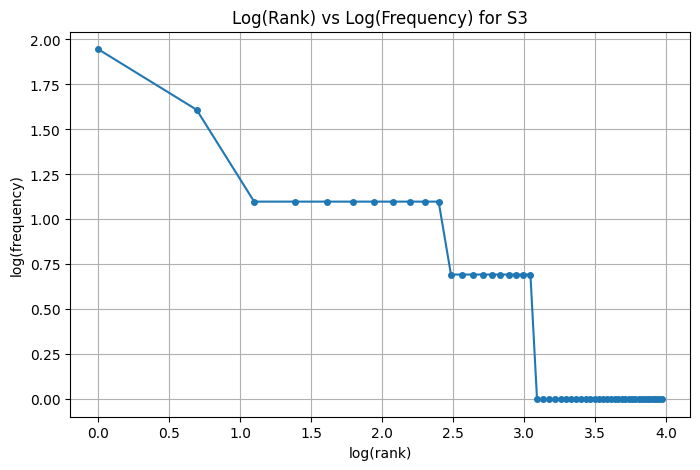


TOP 5 BIGRAMS OF S1:
('restarting', 'the') -> 5
('i', 'tried') -> 4
('tried', 'restarting') -> 4
('.', 'i') -> 4
('i', 'have') -> 3

TOP 5 BIGRAMS OF S3:
('tried', 'restarting') -> 4
('tried', 'several') -> 3
('several', 'times') -> 3
('stopped', 'responding') -> 3
('worked', 'yesterday') -> 3

TTR COMPARISON
S1 - All tokens -> 0.4293
S2 - No punctuation -> 0.4805
S3 - Final tokens -> 0.5824
S4 - Porter stemmed S3 -> 0.5495


In [11]:
# Your code
from collections import Counter
from nltk.util import bigrams
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

S1 = [
    token
    for result in processed.values()
    for token in result["tokens"]
]

S2 = [
    token
    for token in S1
    if not is_punct(token)
]

S3 = [
    token
    for result in processed.values()
    for token in result["final"]
]

porter = PorterStemmer()

S4 = [
    porter.stem(token)
    for token in S3
]


def get_statistics(tokens):

    total_tokens = len(tokens)
    unique_tokens = len(set(tokens))

    if total_tokens == 0:
        ttr = 0
    else:
        ttr = unique_tokens / total_tokens

    return total_tokens, unique_tokens, ttr


statistics = []

for name, corpus in [
    ("S1 - All tokens", S1),
    ("S2 - No punctuation", S2),
    ("S3 - Final tokens", S3),
    ("S4 - Porter stemmed S3", S4)
]:

    total, unique, ttr = get_statistics(corpus)

    statistics.append({
        "Corpus": name,
        "Total Tokens": total,
        "Unique Tokens": unique,
        "TTR": round(ttr, 4)
    })


stats_table = pd.DataFrame(statistics)

print("CORPUS STATISTICS")

display(stats_table)

print("\nTOP 10 WORDS OF S1:")
for word, frequency in Counter(S1).most_common(10):
    print(f"{word:15} {frequency}")


print("\nTOP 10 WORDS OF S3:")
for word, frequency in Counter(S3).most_common(10):
    print(f"{word:15} {frequency}")

frequency_s3 = Counter(S3)

sorted_frequencies = sorted(
    frequency_s3.values(),
    reverse=True
)

ranks = np.arange(
    1,
    len(sorted_frequencies) + 1
)

frequencies = np.array(sorted_frequencies)


plt.figure(figsize=(8, 5))

plt.plot(
    np.log(ranks),
    np.log(frequencies),
    marker="o",
    markersize=4
)

plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Log(Rank) vs Log(Frequency) for S3")
plt.grid(True)

plt.show()

S1_bigram_counter = Counter()
S3_bigram_counter = Counter()

for result in processed.values():

    S1_bigram_counter.update(
        bigrams(result["tokens"])
    )

    S3_bigram_counter.update(
        bigrams(result["final"])
    )


print("\nTOP 5 BIGRAMS OF S1:")

for pair, frequency in S1_bigram_counter.most_common(5):
    print(pair, "->", frequency)


print("\nTOP 5 BIGRAMS OF S3:")

for pair, frequency in S3_bigram_counter.most_common(5):
    print(pair, "->", frequency)

print("\nTTR COMPARISON")

for _, row in stats_table.iterrows():
    print(
        row["Corpus"],
        "->",
        row["TTR"]
    )

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:* TTR changes from S1 to S4 because preprocessing changes both the corpus size and its vocabulary. From S1 to S3, punctuation and stopwords are removed, eliminating many highly frequent tokens. From S3 to S4, Porter stemming maps different morphological forms to common stems, for example working → work, opening → open, and restarting → restart. This reduces the number of distinct word types. Since TTR is the number of unique tokens divided by the total number of tokens, these changes alter the TTR.

(a) Why does TTR change from S1 to S4?

TTR changes because punctuation and stopwords are removed between S1 and S3, while stemming in S4 merges different morphological forms into common stems. For example, working, opening, and restarting are reduced to work, open, and restart. This changes the number of unique token types relative to the total number of tokens, and therefore changes TTR.

(b) One example where word_tokenize() and your tokenizer differ

For isn't, my tokenizer returns isn't as a single token, whereas word_tokenize() returns is and n't. This happens because my regular expression explicitly treats apostrophe-connected contractions as single tokens.

(c) One undesirable stemming result

Lancaster stemming produces an undesirable result for opening, reducing it to op. The stem is overly aggressive and loses the meaningful lexical root open.

(d) POS-aware lemmatization preserves meaning better than stemming

For the noun printer, Lancaster stemming may reduce it to print, changing the device noun into a different lexical form. POS-aware WordNet lemmatization recognizes it as a noun and preserves printer. Therefore, lemmatization preserves the intended meaning better than mechanical stemming.